In [2]:
import numpy as np 
import h5py 
import matplotlib.pyplot as plt 
import os 

fft = lambda inp, dim: np.fft.fftshift(np.fft.fft(np.fft.fftshift(inp, axes=(dim,)), axis=dim), axes=(dim,))
ifft = lambda inp, dim: np.fft.ifftshift(np.fft.ifft(np.fft.ifftshift(inp, axes=(dim,)), axis=dim), axes=(dim,))
fft2 = lambda inp, dim=(0,1): fft(fft(inp,dim[0]),dim[1])
ifft2 = lambda inp, dim=(0,1): ifft(ifft(inp,dim[0]),dim[1])

# Iterative Reconstruction

/var/folders/30/x3_16p4d5j5cq5v20dn6smqm0000gq/T/ipykernel_12174/3533254221.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(np.abs(ksp[:,:,0])))


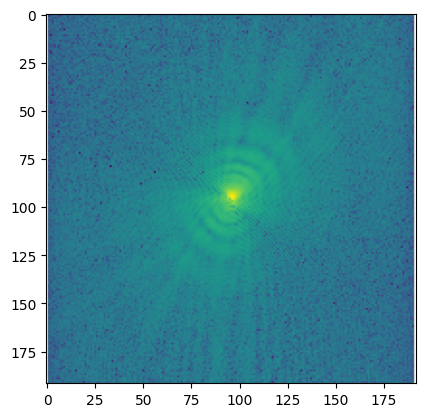

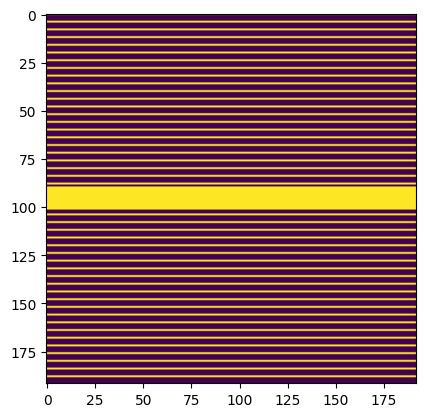

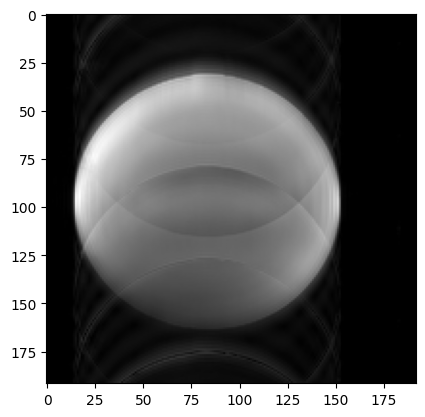

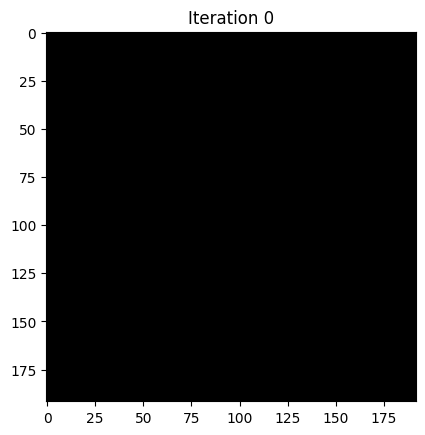

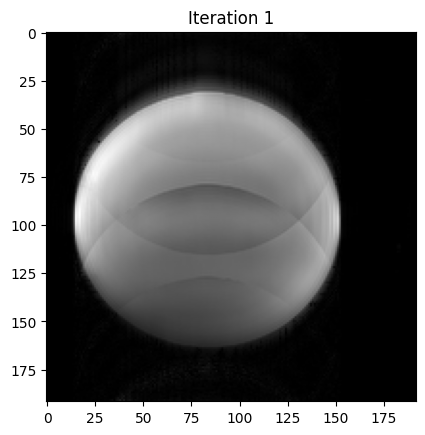

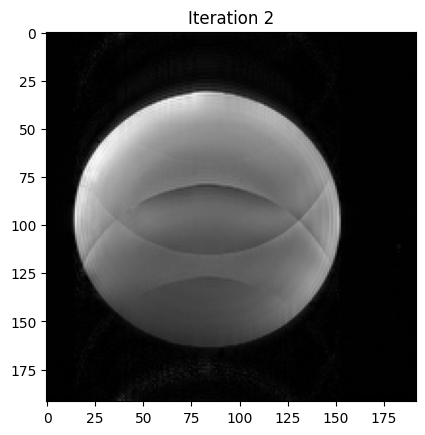

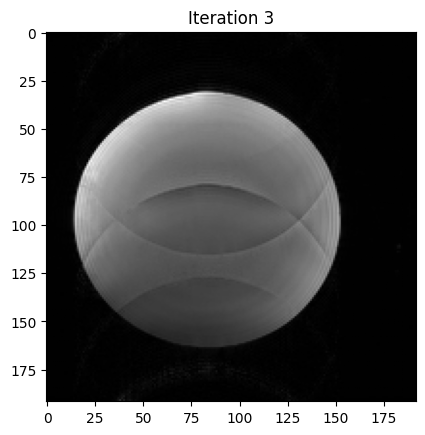

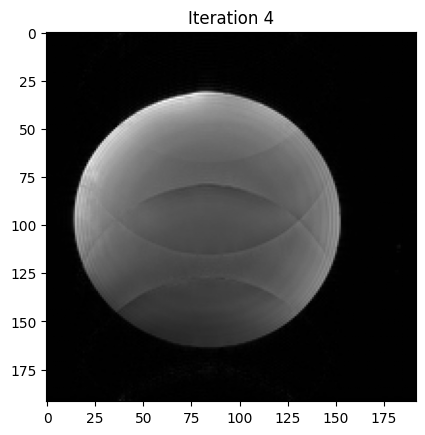

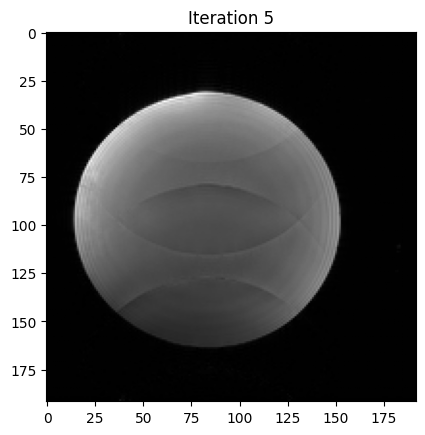

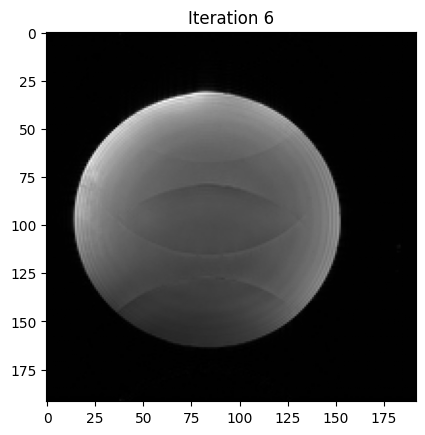

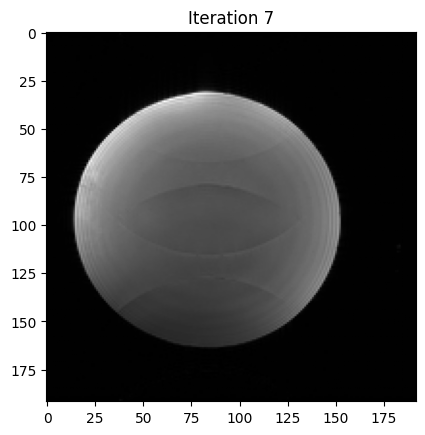

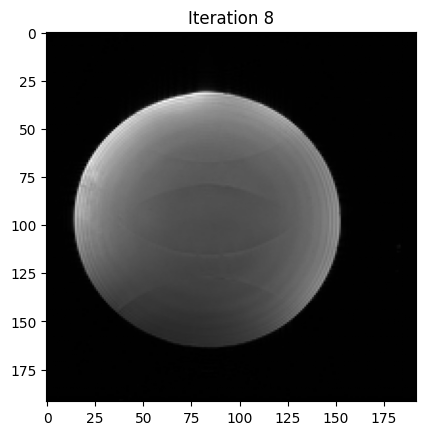

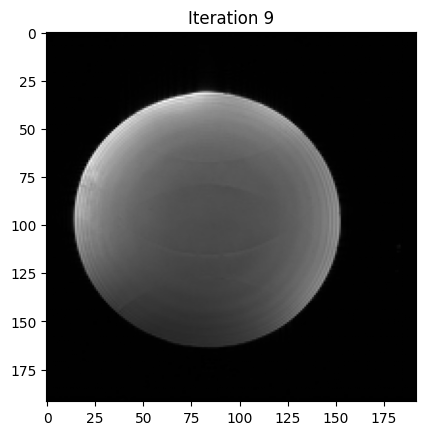

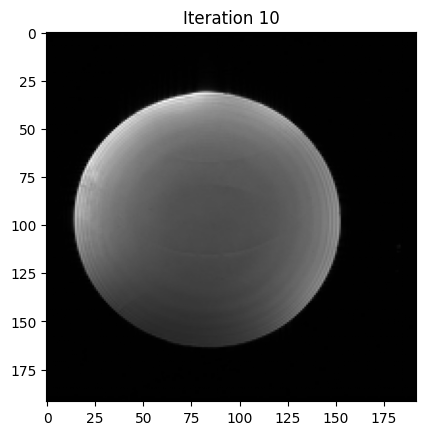

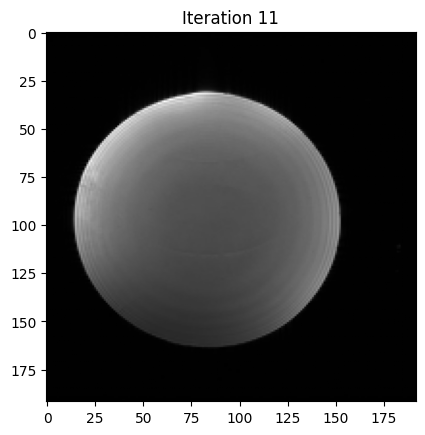

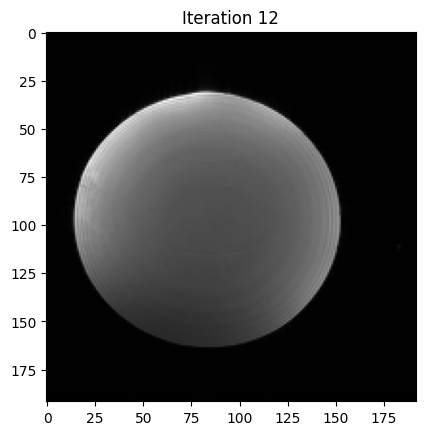

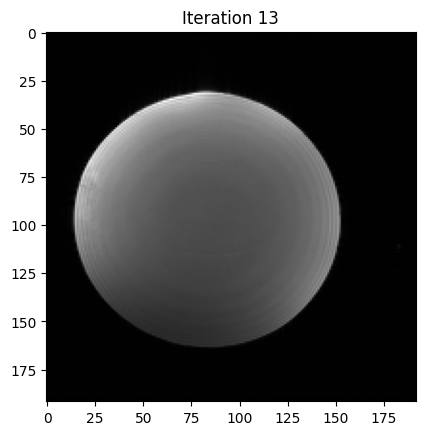

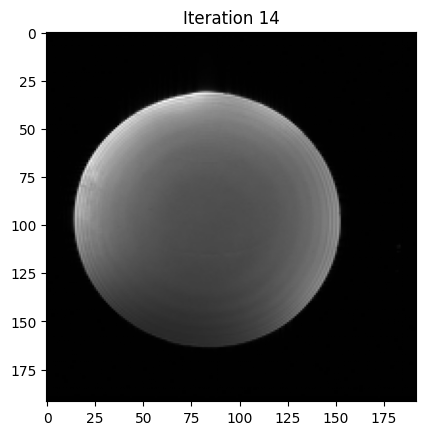

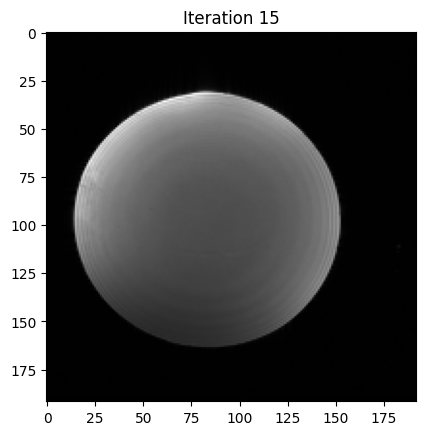

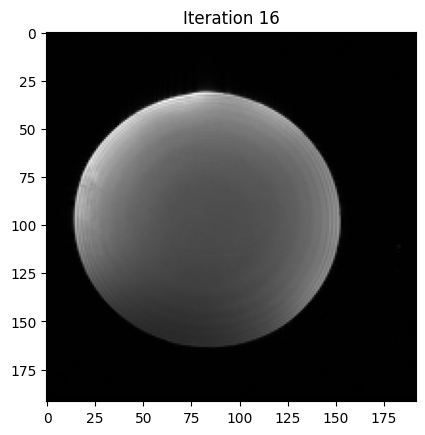

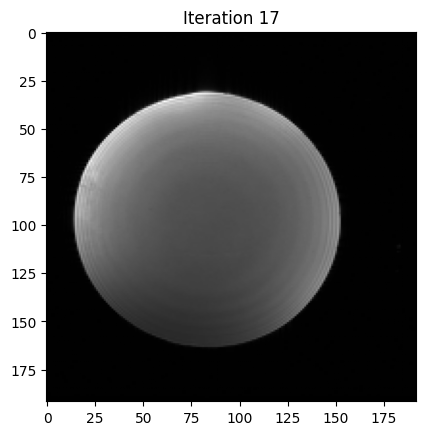

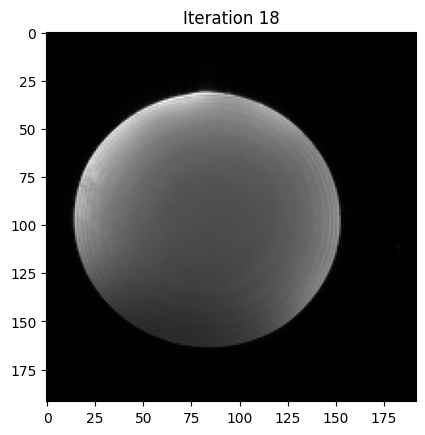

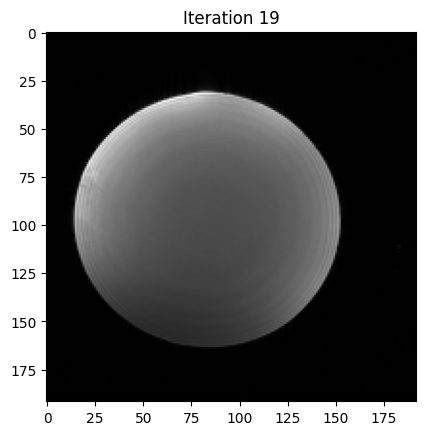

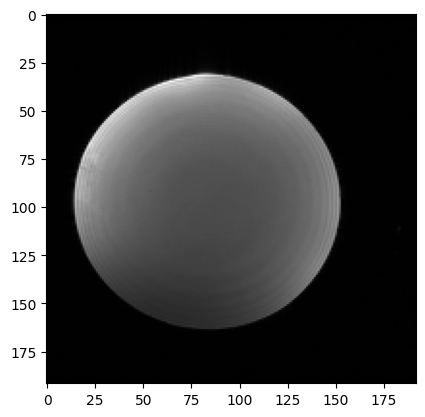

In [19]:

datafile = '/Users/nmickevicius/dev/MCW_BIOP_03-238_MRI/data/fbirn_32ch_kspace.h5'

# !wget https://github.com/nmickevicius/MCW_BIOP_03-238_MRI/raw/main/data/fbirn_32ch_kspace.h5
# datafile = os.path.join(os.getcwd(), 'fbirn_32ch_kspace.h5')

with h5py.File(datafile,'r') as F:
    ksp = F['ksp'][:] # (192, 192, 32)

plt.figure()
plt.imshow(np.log10(np.abs(ksp[:,:,0])))
plt.show()

R = 4
acs = 12 

mask = np.zeros((ksp.shape[0], ksp.shape[1]), dtype=np.float32)
mask[::R,:] = 1.0 
i1 = int(ksp.shape[0]/2 - acs/2)
i2 = i1 + acs 
mask[i1:i2,:] = 1.0 
acs_mask = np.zeros_like(mask) 
acs_mask[i1:i2,:] = 1.0 
r = np.arange(-192/2, 192/2)
# filt = np.exp(-r*r/(2 * ))

plt.figure()
plt.imshow(np.abs(mask))
plt.show()

# get the undersampled k-space 
ksp_us  = ksp * mask[:,:,None]
img_us = ifft2(ksp_us)
rss_us = np.sqrt(np.sum(np.abs(img_us * img_us.conj()), axis=-1))

# estimate coil sensitivity maps from the fully-sampled k-space center
ksp_acs = ksp #* acs_mask[:,:,None]
img_acs = ifft2(ksp_acs)
rss_acs = np.sqrt(np.sum(np.abs(img_acs * img_acs.conj()), axis=-1))
sens = img_acs / rss_acs[:,:,None]

plt.figure()
plt.imshow(rss_us, cmap='gray')
plt.show()

# plt.figure()
# plt.imshow(rss_acs, cmap='gray')
# plt.show()

# build the linear encoding operator 
# x - (192, 192) image that we are reconstructing 

# forward model that brings image guess to undersampled k-space
A  = lambda x: mask[:,:,None] * fft2(sens * x[:,:,None])

# adjoint model that brings k-space to coil-combined image domain
AH = lambda y: np.sum(ifft2(mask[:,:,None] * y) * sens.conj(), axis=-1)

# normal operator: applies both the forward and adjoint operators sequentially
AHA = lambda x: AH(A(x))

# conjugate gradient algorithm 
def conjgrad(AhA, rhs, cgiters=20, cgtol=1e-5):
    x = np.zeros_like(rhs) 
    r = rhs - AhA(x)
    d = np.copy(r)
    dnew = dnot = np.sum(r*np.conj(r))
    for i in range(cgiters):

        plt.figure()
        plt.imshow(np.abs(x), cmap='gray')
        plt.title(f'Iteration {i}')
        plt.show()

        q = AhA(d)
        a = dnew / np.real(np.sum(np.conj(d)*q))
        x = x + a*d 
        r = r - a*q 
        dold = dnew 
        dnew = np.sum(r*np.conj(r))
        d = d * (dnew/dold) + r 
        if np.sqrt(np.abs(dnew)) < cgtol*np.abs(dnot):
            break 
    return x 

rhs = AH(ksp_us)
recon = conjgrad(AHA, rhs, cgtol=0.0)
plt.figure()
plt.imshow(np.abs(recon), cmap='gray')
plt.show()

# Simultaneous Multi-Slice (SMS)

(1, 32, 256, 256)
(3, 32, 256, 256)


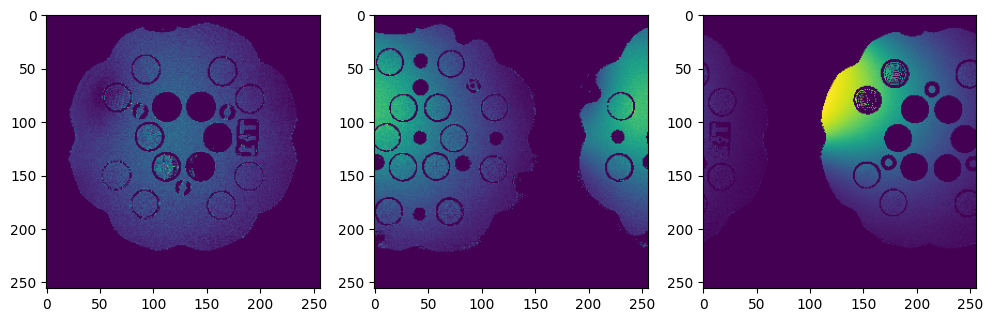

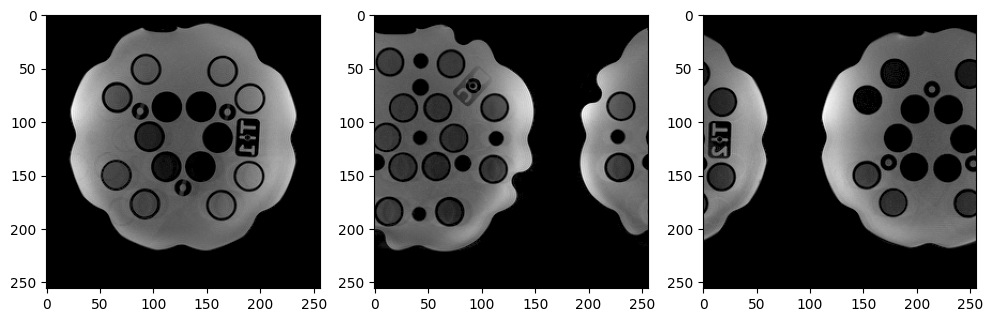

In [30]:
with h5py.File('/Users/nmickevicius/data/20250124_sms_recon_paper_phantom/data_sms3.h5','r') as F:
    accel_data = F['accel_data'][:]
    calib_data = F['calib_data'][:]

print(accel_data.shape)
print(calib_data.shape )

# get coil sensitivity maps 
calib_images = ifft2(calib_data, (-1,-2))
rss = np.sqrt(np.sum(np.abs(calib_images * calib_images.conj()), axis=1, keepdims=True))
sens = calib_images / rss 
mask = np.zeros_like(rss)
mask[rss > 0.07*np.max(np.abs(rss))] = 1.0
sens = mask * sens

fig, ax = plt.subplots(1,3,figsize=(12,4))
for n in range(3): 
    ax[n].imshow(np.abs(sens[n, 0, :, :]))
plt.show()

# bring the SMS-accelerated into the image domain 
img_sms = ifft2(accel_data, (-1,-2))

# 
recon = np.zeros((3, 256, 256), dtype=sens.dtype)

for x in range(256):
    for y in range(256):

        # coil sensitivites for all aliased pixels
        A = sens[:,:,x,y].T

        # aliased  intensity at current pixel
        Y = img_sms[:,:,x,y].T 

        try:
            X = np.linalg.lstsq(A, Y, rcond=None)[0][:,0]
            recon[0,x,y] = X[0]
            recon[1,x,y] = X[1]
            recon[2,x,y] = X[2]
        except:
            pass

fig,ax = plt.subplots(1,3,figsize=(12,4))
for n in range(3):
    ax[n].imshow(np.abs(recon[n,:,:]), cmap='gray')
plt.show()

